# Quickstart

In [1]:
from immunowave import models, spatial
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

## Define a model

In [2]:
model = models.FHNB(
    α=1.0,
    θ=0.1,
    η=1.0,
    ρ=0.0,
    ε=0.0,
    ξ=0.0,
    λ=0.0,
    μ=0.0,
)
model

FHNB(α=1.0, θ=0.1, η=1.0, ρ=0.0, ε=0.0, ξ=0.0, λ=0.0, μ=0.0, n_components=3)

## Initialize fields

Spatial discretization

In [3]:
L = 100.0
lb = -L / 2
n = 100
h = L / (n - 1)

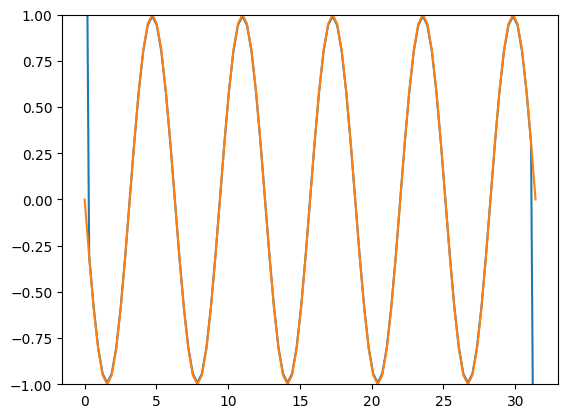

In [4]:
foo = spatial.ScalarField(
    101,
    0.0,
    jnp.pi / 10,
    fn=lambda x: jnp.sin(x),
)

plt.plot(*foo.domain, foo.laplacian().values)
plt.plot(*foo.domain, -jnp.sin(*foo.domain))
plt.ylim(-1, 1)
plt.show()

In [5]:
A = spatial.ScalarField(n, lb, h)
R = spatial.ScalarField(n, lb, h)
B = spatial.ScalarField(n, lb, h, fn=lambda x: jnp.where(jnp.abs(x) < h / 2, 1.0, 0.0))

B.integral()

Array(1.01010101, dtype=float64)

In [6]:
B.laplacian(bc="neumann").values

Array([ 0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
        0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
        0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
        0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
        0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
        0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
        0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.9801,
       -1.9602,  0.9801,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
        0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
        0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
        0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
        0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
        0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
        0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
        0.    ,  0. 

## Define time domain

In [7]:
t0 = 0.0
t1 = 100.0
t = np.linspace(t0, t1, 10)

## Solve

In [8]:
state0 = (A, R, B)

In [9]:
import jax.tree_util as jtu
import diffrax as dx
jtu.tree_structure(dx.ODETerm(model).vf(0.0, state0, None)) == jtu.tree_structure(model(0.0, state0)) == jtu.tree_structure(state0)

True

In [13]:
rtol = 1e-8
atol = 1e-8
stepsize_controller = dx.PIDController(
    pcoeff=0.3, icoeff=0.4, rtol=rtol, atol=atol, dtmax=0.001
)
from immunowave import solvers
solver = solvers.CrankNicolson(rtol=rtol, atol=atol)
discrete_terminating_event = dx.DiscreteTerminatingEvent(
    lambda t, y, args: model.boundary_metric(y) > 1e-3
)
dx.diffeqsolve(
    # term.PDETerm(model),
    dx.ODETerm(model),
    solver,
    t[0],
    t[-1],
    dt0=None,
    discrete_terminating_event=discrete_terminating_event,
    y0=state0,
    # **kwargs,
    saveat=dx.SaveAt(ts=t),
    stepsize_controller=stepsize_controller,
)

TracerBoolConversionError: Attempted boolean conversion of traced array with shape bool[1]..
The error occurred while tracing the function _fn at /Users/wsdewitt/miniconda3/envs/immunowave/lib/python3.11/site-packages/equinox/_eval_shape.py:31 for eval_shape. This value became a tracer due to JAX operations on these lines:

  operation a:f64[] = convert_element_type[new_dtype=float64 weak_type=False] b
    from line /Users/wsdewitt/github/immunowave/immunowave/spatial.py:111:38 (ScalarField.__init__)

  operation a:f64[] = convert_element_type[new_dtype=float64 weak_type=False] b
    from line /Users/wsdewitt/github/immunowave/immunowave/spatial.py:111:28 (ScalarField.__init__)

  operation a:f64[1] = add b c
    from line /Users/wsdewitt/github/immunowave/immunowave/spatial.py:111:18 (ScalarField.__init__)

  operation a:f64[] = convert_element_type[new_dtype=float64 weak_type=False] b
    from line /Users/wsdewitt/github/immunowave/immunowave/spatial.py:111:38 (ScalarField.__init__)


In [ ]:
solution = model.solve(state0, t=t, dt0=None)

TracerBoolConversionError: Attempted boolean conversion of traced array with shape bool[1]..
The error occurred while tracing the function _fn at /Users/wsdewitt/miniconda3/envs/immunowave/lib/python3.11/site-packages/equinox/_eval_shape.py:31 for eval_shape. This value became a tracer due to JAX operations on these lines:

  operation a:f64[] = convert_element_type[new_dtype=float64 weak_type=False] b
    from line /Users/wsdewitt/github/immunowave/immunowave/spatial.py:110:38 (ScalarField.__init__)

  operation a:f64[] = convert_element_type[new_dtype=float64 weak_type=False] b
    from line /Users/wsdewitt/github/immunowave/immunowave/spatial.py:110:28 (ScalarField.__init__)

  operation a:f64[1] = add b c
    from line /Users/wsdewitt/github/immunowave/immunowave/spatial.py:110:18 (ScalarField.__init__)

  operation a:f64[] = convert_element_type[new_dtype=float64 weak_type=False] b
    from line /Users/wsdewitt/github/immunowave/immunowave/spatial.py:110:38 (ScalarField.__init__)


In [ ]:
import jax

jax.tree_util.tree_map(prod, (1.0, 2.0))

(2.0, 4.0)

## Plot

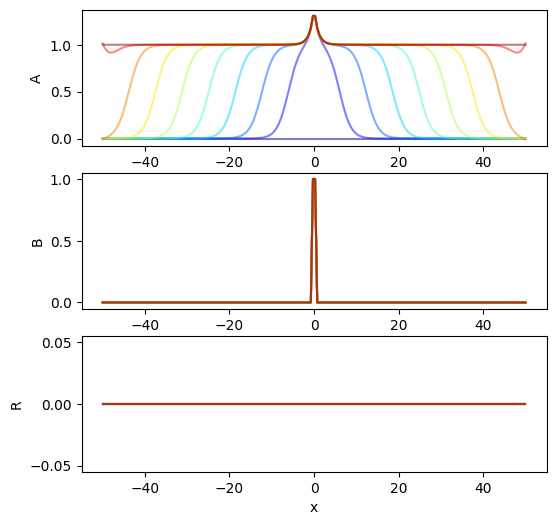

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(6, 2 * 3))
n = 20
import matplotlib.pylab as pl

colors = pl.cm.jet(np.linspace(0, 1, len(t)))
for i in range(len(t)):
    ti = t[i]
    statei = {name: values[i] for name, values in solution.ys.items()}
    iwm.plot(model, statei, axes, alpha=0.5, color=colors[i])
plt.show()